# E1 213 Pattern Recognition and Neural Network - Assignment 2
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from torch import nn
import os
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from sklearn.metrics import confusion_matrix, precision_recall_curve, cohen_kappa_score
device = "mps" if torch.mps.is_available() else "cpu"
from time import time

from src import *

### **Phase 1**: The MLP Baseline and Gradient Flow

In [2]:
DATA_DIR = '/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data'
time_series_file_path = os.path.join(DATA_DIR, 'delhi_aqi.csv')

data_regression = TimeSeriesDataset(time_series_file_path, 72,24)
data_classify = TimeSeriesDataset(time_series_file_path, 72,24, classify=True)

#### **Problem 1.1**: Flattened Temporal MLP(Regression)

In [3]:
torch.manual_seed(25)
torch.mps.manual_seed(25)

N = len(data_regression)
train_end = int(0.7*N)
val_end = int(0.85*N)

X_train = Subset(data_regression, range(0, train_end))
X_val = Subset(data_regression, range(train_end, val_end))
X_test = Subset(data_regression, range(val_end, N))


train_loader = DataLoader(X_train, batch_size=32, shuffle=False)
val_loader = DataLoader(X_val, batch_size=32, shuffle=False)
test_loader = DataLoader(X_test, batch_size=32, shuffle=False)

model = Temporal_MLP(input_dim= data_regression.input_dim).to(device)
    
learning_rate = 1e-3
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
epochs = 100
    
train_loop(train_loader, val_loader, model, loss_fn, optimizer, epochs, patience=10)
_,_ = test_loop(test_loader, model, loss_fn)

Epoch 0: Training Loss: 0.7532, Validation Loss: 0.2368
Epoch 10: Training Loss: 0.6068, Validation Loss: 0.2303
Early stopping at epoch 19. Best Validation Loss: 0.2291
Test Loss (MSE): 0.8568


#### **Problem 1.2**: Vanishing Gradient Proof 

Epoch 0: Training Loss: 0.7843, Validation Loss: 0.2315


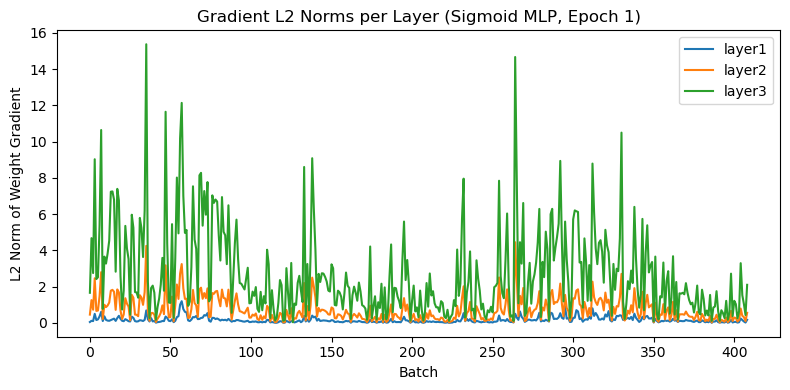

In [4]:
torch.manual_seed(25)
torch.mps.manual_seed(25)

sigmoid_model = Temporal_MLP(input_dim= data_regression.input_dim, sigmoid=True).to(device)
sigmoid_optimizer = torch.optim.Adam(sigmoid_model.parameters(), lr=learning_rate)

grad_norms = train_loop(train_loader, val_loader, sigmoid_model, loss_fn,sigmoid_optimizer, epochs, patience=10, backward_hook=True)

batches = range(len(grad_norms['layer1']))
plt.figure(figsize=(8, 4))
for layer_name, norms in grad_norms.items():
    plt.plot(norms, label=layer_name)
plt.xlabel('Batch')
plt.ylabel('L2 Norm of Weight Gradient')
plt.title('Gradient L2 Norms per Layer (Sigmoid MLP, Epoch 1)')
plt.legend()
plt.tight_layout()
plt.savefig('gradient_flow_sigmoid.png', dpi=150)
plt.show()

#### **Problem 1.3**: Imbalanced Threshold Classification 

Epoch 0: Training Loss: 0.5526, Validation Loss: 0.3949
Epoch 10: Training Loss: 0.4878, Validation Loss: 0.3881
Epoch 20: Training Loss: 0.4645, Validation Loss: 0.3924
Early stopping at epoch 20. Best Validation Loss: 0.3881
Standard BCE:
[[ 758  248]
 [ 706 1090]]
Epoch 0: Training Loss: 0.6714, Validation Loss: 0.4955
Epoch 10: Training Loss: 0.5864, Validation Loss: 0.4894
Early stopping at epoch 18. Best Validation Loss: 0.4882
Weighted BCE:
[[ 630  376]
 [ 386 1410]]


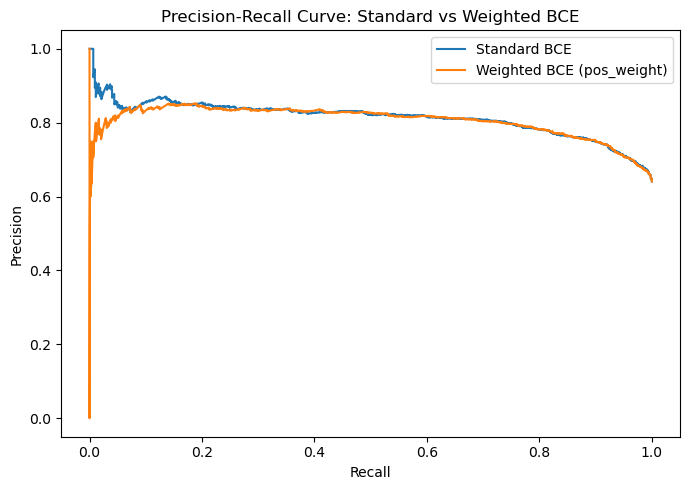

In [5]:
torch.manual_seed(0)
torch.mps.manual_seed(0)

N = len(data_classify)

train_end = int(0.7*N)
val_end = int(0.85*N)

X_train_classify = Subset(data_classify, range(0, train_end))
X_val_classify = Subset(data_classify, range(train_end, val_end))
X_test_classify = Subset(data_classify, range(val_end, N))

train_loader_clasify = DataLoader(X_train_classify, batch_size=32, shuffle=False)
val_loader_clasify = DataLoader(X_val_classify, batch_size=32, shuffle=False)
test_loader_clasify = DataLoader(X_test_classify, batch_size=32, shuffle=False)

n_neg = sum(1 for _, y in X_train_classify if y == 0)
n_pos = sum(1 for _, y in X_train_classify if y == 1)
pos_weight = torch.tensor([n_neg / n_pos]).to(device)

learning_rate = 1e-3
epochs = 100

model_std = Temporal_MLP(input_dim= data_classify.input_dim,classify=True).to(device)
loss_fn_std = nn.BCELoss()
optimizer_std = torch.optim.Adam(model_std.parameters(), lr=learning_rate)
train_loop(train_loader_clasify, val_loader_clasify, model_std, loss_fn_std, optimizer_std, epochs)
print("Standard BCE:")
probs_std, y_true = test_loop(test_loader_clasify, model_std, loss_fn_std, classify=True)


model_weighted = Temporal_MLP(input_dim=data_classify.input_dim).to(device)
loss_fn_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_weighted = torch.optim.Adam(model_weighted.parameters(), lr=learning_rate)
train_loop(train_loader_clasify, val_loader_clasify, model_weighted, loss_fn_weighted, optimizer_weighted, epochs)
print("Weighted BCE:")
probs_weighted, _ = test_loop(test_loader_clasify, model_weighted, loss_fn_weighted, classify=True, Logit_loss=True)


prec_std, rec_std, _ = precision_recall_curve(y_true, probs_std)
prec_w, rec_w, _ = precision_recall_curve(y_true, probs_weighted)
plt.figure(figsize=(7, 5))
plt.plot(rec_std, prec_std, label='Standard BCE')
plt.plot(rec_w,   prec_w,   label='Weighted BCE (pos_weight)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Standard vs Weighted BCE')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_1_3.png', dpi=150)
plt.show()

### **Phase 2**: CNNs & Spatial Hierarchies (PlantVillage)

In [2]:
DATA_DIR = '/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data'
image_file_path = os.path.join(DATA_DIR, 'plantvillage_dataset/segmented')

transform = transforms.Resize((128, 128))
plantvillage_classify = PlantVillageDataset(image_file_path, transform=transform)
plantvillage_data_severity = PlantVillageSeverityDataset(image_file_path, transform=transform)

Pre-computing severity for 54306 images...
  5000/54306
  10000/54306
  15000/54306
  20000/54306
  25000/54306
  30000/54306
  35000/54306
  40000/54306
  45000/54306
  50000/54306
Done.


#### **Problem 2.4**: CNN from Scratch & Receptive Fields

In [3]:
single_image = plantvillage_classify[0][0].to(device)

cnn_model = ownCNN(128,len(plantvillage_classify.class_to_idx)).to(device)

_ = cnn_model.forward(single_image.unsqueeze(0), print_shapes=True)

print(f"CNN Receptive field : {cnn_model.receptive_field()}")

Input:          (1, 3, 128, 128)
Conv2d      : (1, 8, 128, 128)
BatchNorm2d : (1, 8, 128, 128)
MaxPool2d   : (1, 8, 64, 64)
Conv2d      : (1, 16, 64, 64)
BatchNorm2d : (1, 16, 64, 64)
MaxPool2d   : (1, 16, 32, 32)
Conv2d      : (1, 32, 32, 32)
BatchNorm2d : (1, 32, 32, 32)
MaxPool2d   : (1, 32, 16, 16)
Flatten     : (1, 8192)
Linear      : (1, 256)
Linear      : (1, 64)
Linear      : (1, 38)
Output:         (1, 38)
CNN Receptive field : 22


#### **Problem 2.5**: CNN Regression Head

In [ ]:
np.random.seed(25)
torch.manual_seed(25)
torch.mps.manual_seed(25)

cnn_model = ownCNN(128,1).to(device)

N = len(plantvillage_data_severity)
index = np.random.permutation(N)

train_indices = index[:int(0.7*N)]
val_indices   = index[int(0.7*N):int(0.85*N)]
test_indices  = index[int(0.85*N):]

train_dataset = Subset(plantvillage_data_severity, train_indices)
val_dataset   = Subset(plantvillage_data_severity, val_indices)
test_dataset  = Subset(plantvillage_data_severity, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

learning_rate = 1e-2
loss_fn = nn.MSELoss()
loss_fn_test = nn.L1Loss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=learning_rate)
epochs = 10
print("Entering training loop")
train_loop(train_dataloader, val_dataloader, cnn_model, loss_fn, optimizer, epochs, patience=10)
print("Entering test loop")
_,_ = test_loop(test_dataloader, cnn_model, loss_fn_test)

Entering training loop
Epoch 0: Training Loss: 45.2449, Validation Loss: 0.1299
Entering test loop
Test Loss (MSE): 0.2392


#### **Problem 2.6**: Translation Invariance

In [3]:
np.random.seed(25)
torch.manual_seed(25)
torch.mps.manual_seed(25)

cnn_model = ownCNN(128,len(plantvillage_classify.class_to_idx)).to(device)

N = len(plantvillage_classify)
index = np.random.permutation(N)

train_indices = index[:int(0.7*N)]
val_indices   = index[int(0.7*N):int(0.85*N)]
test_indices  = index[int(0.85*N):int(0.85*N)+100]

train_dataset = Subset(plantvillage_classify, train_indices)
val_dataset   = Subset(plantvillage_classify, val_indices)
test_dataset  = Subset(plantvillage_classify, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)


shift_transform = transforms.Compose([transforms.Resize((128, 128)),transforms.Lambda(lambda img: TF.affine(img, angle=0, translate=(5, 5), scale=1.0, shear=0))])
shifted_test_dataset = PlantVillageDataset(image_file_path, transform=shift_transform)
shifted_test_dataset_100 = Subset(shifted_test_dataset, test_indices)
shifted_test_loader = DataLoader(shifted_test_dataset_100, batch_size=32, shuffle=False)

learning_rate = 1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=learning_rate)
epochs = 15
print("Entering training loop")
train_loop(train_dataloader, val_dataloader, cnn_model, loss_fn, optimizer, epochs, patience=10)


acc_no_shift = accuracy(test_dataloader, cnn_model)
acc_shifted  = accuracy(shifted_test_loader, cnn_model)

print(f"Accuracy without shift: {acc_no_shift*100:.2f}%")
print(f"Accuracy with 5px shift: {acc_shifted*100:.2f}%")
print(f"Performance drop: {(acc_no_shift - acc_shifted)*100:.2f}%")


Entering training loop
Epoch 0: Training Loss: 1.2250, Validation Loss: 0.7618
Epoch 10: Training Loss: 0.0765, Validation Loss: 0.5566
Early stopping at epoch 13. Best Validation Loss: 0.4788
Accuracy without shift: 86.00%
Accuracy with 5px shift: 77.00%
Performance drop: 9.00%


### **Phase 3**: RNNs & Sequential Memory (Air Quality)

In [6]:
DATA_DIR = '/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data'
time_series_file_path = os.path.join(DATA_DIR, 'delhi_aqi.csv')

data_regression = TimeSeriesDataset(time_series_file_path, 72,24)

#### **Problem 3.7**: Vanilla RNN from scratch

In [12]:
torch.manual_seed(25)
torch.mps.manual_seed(25)

N = len(data_regression)

train_indices = list(range(int(0.7*N)))
val_indices   = list(range(int(0.7*N), int(0.85*N)))
test_indices  = list(range(int(0.85*N), N))

train_dataset = Subset(data_regression, train_indices)
val_dataset   = Subset(data_regression, val_indices)
test_dataset  = Subset(data_regression, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

rnn_model = OwnVanillaRNN(1, 64, 1).to(device)
learning_rate = 1e-3
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)
epochs = 100
print("Entering training loop")
train_loop(train_dataloader, val_dataloader, rnn_model, loss_fn, optimizer, epochs, patience=10)
print("Entering test loop")
_,_ = test_loop(test_dataloader, rnn_model, loss_fn)

Entering training loop
Epoch 0: Training Loss: 0.6591, Validation Loss: 0.2421
Epoch 10: Training Loss: 0.6407, Validation Loss: 0.2418
Early stopping at epoch 11. Best Validation Loss: 0.2399
Entering test loop
Test Loss (MSE): 0.9198


#### **Problem 3.8**: BPTT Decay

In [13]:
rnn_model = OwnVanillaRNN(1, 64, 1).to(device)
hidden_states = rnn_model.bptt_decay()

||dL/dh|| at t=100: 1.79e-01
||dL/dh|| at t=50:  0.00e+00
||dL/dh|| at t=0:   0.00e+00


#### **Problem 3.9**: Exploding Gradients

In [14]:
N = len(data_regression)

train_indices = list(range(int(0.7*N)))
val_indices   = list(range(int(0.7*N), int(0.85*N)))
test_indices  = list(range(int(0.85*N), N))

train_dataset = Subset(data_regression, train_indices)
val_dataset   = Subset(data_regression, val_indices)
test_dataset  = Subset(data_regression, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

rnn_model = OwnVanillaRNN(1, 64, 1).to(device)
learning_rate = 10
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(rnn_model.parameters(), lr=learning_rate)
epochs = 100
largest_singular_value = train_loop_rnn(train_dataloader, rnn_model, loss_fn, optimizer)
print(f"Largest Singular Value of Recurrent Weight Matrix during Training: {largest_singular_value:.4f}")

Epoch Number:1
Largest Singular Value of Recurrent Weight Matrix during Training: 1.1057


### **Phase 4**: LSTMs, GRUs, & Context (Air Quality)

In [15]:
DATA_DIR = '/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data'
time_series_file_path = os.path.join(DATA_DIR, 'delhi_aqi.csv')

data_regression = TimeSeriesDataset(time_series_file_path, 72,24)
data_regression_encoder_decoder = EncoderDecoderDataset(time_series_file_path, 72,24)

#### **Problem 4.10**: LSTM Gradient Rescue

In [16]:
model = LSTM(1, 64, 1).to(device)
hidden_states = model.bptt_decay()

||dL/dh|| at t=100: 1.32e-01
||dL/dh|| at t=50:  1.17e-12
||dL/dh|| at t=0:   1.59e-22


#### **Problem 4.11**: GRU vs LSTM Efficiency

In [20]:
torch.manual_seed(30)
torch.mps.manual_seed(30)

model_LSTM = LSTM(1, 128, 1).to(device)
model_GRU = GRU(1, 128, 1).to(device)

print(f"Number of trainable parameters in LSTM: {trainable_parameters(model_LSTM)}")
print(f"Number of trainable parameters in GRU: {trainable_parameters(model_GRU)}")

N = len(data_regression)

train_indices = list(range(int(0.7*N)))
val_indices   = list(range(int(0.7*N), int(0.85*N)))
test_indices  = list(range(int(0.85*N), N))

train_dataset = Subset(data_regression, train_indices)
val_dataset   = Subset(data_regression, val_indices)
test_dataset  = Subset(data_regression, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

learning_rate =1e-3
loss_fn = nn.MSELoss()
optimizer1 = torch.optim.Adam(model_LSTM.parameters(), lr=learning_rate)
optimizer2 = torch.optim.Adam(model_GRU.parameters(), lr=learning_rate)
epochs = 100

start_time_lstm = time()
train_loop(train_dataloader, val_dataloader, model_LSTM, loss_fn, optimizer1, epochs, patience=10)
end_time_lstm = time()
print(f"LSTM Training Time: {end_time_lstm - start_time_lstm:.2f} seconds") 
_,_ = test_loop(test_dataloader, model_LSTM, loss_fn)

start_time_gru = time()
train_loop(train_dataloader, val_dataloader, model_GRU, loss_fn, optimizer2, epochs, patience=10)
end_time_gru = time()
print(f"GRU Training Time: {end_time_gru - start_time_gru:.2f} seconds")
_,_ = test_loop(test_dataloader, model_GRU, loss_fn)

Number of trainable parameters in LSTM: 67201
Number of trainable parameters in GRU: 50433
Epoch 0: Training Loss: 0.7556, Validation Loss: 0.2535
Epoch 10: Training Loss: 0.6504, Validation Loss: 0.2687
Early stopping at epoch 11. Best Validation Loss: 0.2530
LSTM Training Time: 45.88 seconds
Test Loss (MSE): 0.8795
Epoch 0: Training Loss: 0.7180, Validation Loss: 0.2480
Epoch 10: Training Loss: 0.6426, Validation Loss: 0.2544
Early stopping at epoch 10. Best Validation Loss: 0.2480
GRU Training Time: 99.19 seconds
Test Loss (MSE): 0.9690


#### **Problem 4.12**: Sequence to Sequence Forecasting

In [21]:
model_LSTM = EncoderDecoderLSTM(1, 64, 1, 24).to(device)

N = len(data_regression_encoder_decoder)

train_indices = list(range(int(0.7*N)))
val_indices   = list(range(int(0.7*N), int(0.85*N)))
test_indices  = list(range(int(0.85*N), N))

train_dataset = Subset(data_regression_encoder_decoder, train_indices)
val_dataset   = Subset(data_regression_encoder_decoder, val_indices)
test_dataset  = Subset(data_regression_encoder_decoder, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

learning_rate =1e-3
loss_fn = nn.MSELoss()
optimizer1 = torch.optim.Adam(model_LSTM.parameters(), lr=learning_rate)
epochs = 100

train_loop(train_dataloader, val_dataloader, model_LSTM, loss_fn, optimizer1, epochs, patience=10)
pred_list, y_list = test_loop(test_dataloader, model_LSTM, loss_fn)

Epoch 0: Training Loss: 0.8789, Validation Loss: 0.2556
Epoch 10: Training Loss: 0.5688, Validation Loss: 0.2151
Epoch 20: Training Loss: 0.4521, Validation Loss: 0.2007
Epoch 30: Training Loss: 0.4240, Validation Loss: 0.1935
Epoch 40: Training Loss: 0.3810, Validation Loss: 0.1935
Epoch 50: Training Loss: 0.3640, Validation Loss: 0.1980
Early stopping at epoch 51. Best Validation Loss: 0.1895
Test Loss (MSE): 0.6591


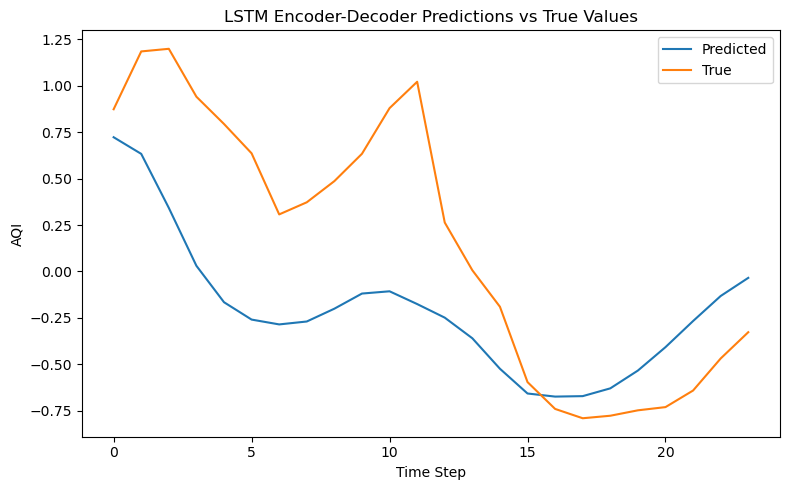

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(pred_list[1], label='Predicted')
plt.plot(y_list[1], label='True')
plt.xlabel('Time Step')
plt.ylabel('AQI')
plt.title('LSTM Encoder-Decoder Predictions vs True Values')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_encoder_decoder_predictions.png', dpi=150)
plt.show()

### **Phase 5**: Transformers & Attention

In [2]:
DATA_DIR = '/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data'
time_series_file_path = os.path.join(DATA_DIR, 'delhi_aqi.csv')
image_file_path = os.path.join(DATA_DIR, 'plantvillage_dataset/segmented')

transform = transforms.Resize((128, 128))
data_regression = TimeSeriesDataset(time_series_file_path, 72,24)
plantvillage_dataset_vit = PlantVillageDatasetViT(image_file_path, transform=transform)
plantvillage_classify = PlantVillageDataset(image_file_path, transform=transform)

#### **Problem 5.13**: Scaled Dot-Product Attention

In [37]:
torch.manual_seed(25)
torch.mps.manual_seed(25)

attention_model = SingleHeadTansformer(1, 128, 1).to(device)

N = len(data_regression)

train_indices = list(range(int(0.7*N)))
val_indices   = list(range(int(0.7*N), int(0.85*N)))
test_indices  = list(range(int(0.85*N), N))

train_dataset = Subset(data_regression, train_indices)
val_dataset   = Subset(data_regression, val_indices)
test_dataset  = Subset(data_regression, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

learning_rate =1e-3
loss_fn = nn.MSELoss()
optimizer1 = torch.optim.Adam(attention_model.parameters(), lr=learning_rate)
epochs = 100

train_loop(train_dataloader, val_dataloader, attention_model, loss_fn, optimizer1, epochs, patience=10)
_,_ = test_loop(test_dataloader, attention_model, loss_fn)

Epoch 0: Training Loss: 0.8967, Validation Loss: 0.2429
Epoch 10: Training Loss: 0.7823, Validation Loss: 0.2416
Epoch 20: Training Loss: 0.7895, Validation Loss: 0.2235
Early stopping at epoch 28. Best Validation Loss: 0.2223
Test Loss (MSE): 1.1395


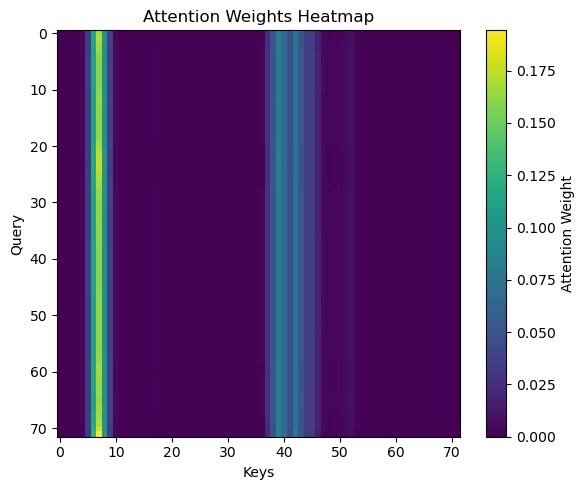

In [38]:
attention_weight_matrix = attention_model.get_attention_weights(test_dataset[0][0].to(device).unsqueeze(0))

plt.figure(figsize=(6, 5))
plt.imshow(attention_weight_matrix.squeeze(0), cmap='viridis', aspect='auto')
plt.colorbar(label='Attention Weight')
plt.xlabel('Keys')
plt.ylabel('Query')
plt.title('Attention Weights Heatmap')
plt.tight_layout()
plt.savefig('attention_weights_heatmap.png', dpi=150)
plt.show()

#### **Problem 5.14**: The Necessity of Positional Encoding

In [41]:
torch.manual_seed(25)
torch.mps.manual_seed(25)

attention_model = SingleHeadTansformer(1, 64, 1).to(device)
attention_model_with_positional = SingleHeadTransformerwithSinusoidalEmbeddings(1, 64, 1).to(device)

N = len(data_regression)

train_indices = list(range(int(0.7*N)))
val_indices   = list(range(int(0.7*N), int(0.85*N)))
test_indices  = list(range(int(0.85*N), N))

train_dataset = Subset(data_regression, train_indices)
val_dataset   = Subset(data_regression, val_indices)
test_dataset  = Subset(data_regression, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

learning_rate =1e-2
loss_fn = nn.MSELoss()
optimizer1 = torch.optim.Adam(attention_model.parameters(), lr=learning_rate)
optimizer2 = torch.optim.Adam(attention_model_with_positional.parameters(), lr=learning_rate)
epochs = 100

train_loop(train_dataloader, val_dataloader, attention_model, loss_fn, optimizer1, epochs, patience=10)
_,_ = test_loop(test_dataloader, attention_model, loss_fn)

train_loop(train_dataloader, val_dataloader, attention_model_with_positional, loss_fn, optimizer2, epochs, patience=10)
_,_ = test_loop(test_dataloader, attention_model_with_positional, loss_fn)

Epoch 0: Training Loss: 0.9271, Validation Loss: 0.3223
Epoch 10: Training Loss: 0.7726, Validation Loss: 0.2650
Epoch 20: Training Loss: 0.8196, Validation Loss: 0.2756
Epoch 30: Training Loss: 0.7917, Validation Loss: 0.2449
Epoch 40: Training Loss: 0.8502, Validation Loss: 0.2642
Early stopping at epoch 47. Best Validation Loss: 0.2344
Test Loss (MSE): 1.1496
Epoch 0: Training Loss: 0.9007, Validation Loss: 0.2573
Epoch 10: Training Loss: 0.7103, Validation Loss: 0.2429
Early stopping at epoch 14. Best Validation Loss: 0.2295
Test Loss (MSE): 0.8872


#### **Problem 5.15**: Vision Transformer (ViT)

In [5]:
np.random.seed(25)
torch.manual_seed(25)
torch.mps.manual_seed(25)

attention_model = SingleHeadTansformer(input_dim=768, model_dim=64, output_dim=38).to(device)

N = len(plantvillage_dataset_vit)
index = np.random.permutation(N)

train_indices = index[:int(0.7*N)]
val_indices   = index[int(0.7*N):int(0.85*N)]
test_indices  = index[int(0.85*N):]

train_dataset = Subset(plantvillage_dataset_vit, train_indices)
val_dataset   = Subset(plantvillage_dataset_vit, val_indices)
test_dataset  = Subset(plantvillage_dataset_vit, test_indices)
test_dataset_cnn  = Subset(plantvillage_classify, test_indices)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)
test_dataloader_cnn = DataLoader(test_dataset_cnn, batch_size= 32, shuffle=False)

learning_rate =1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(attention_model.parameters(), lr=learning_rate)
epochs = 20

train_loop(train_dataloader, val_dataloader, attention_model, loss_fn, optimizer1, epochs, patience=10)

cnn_model = ownCNN(128,38).to(device)
cnn_model.load_state_dict(torch.load('cnn_model_weights.pth'))
cnn_accuracy = accuracy(test_dataloader_cnn, cnn_model)
attention_accuracy = accuracy(test_dataloader, attention_model)

cnn_number_of_parameters = count_trainable(cnn_model)
attention_number_of_parameters = count_trainable(attention_model)

print(f"CNN Accuracy: {cnn_accuracy*100:.2f}%, Parameters: {cnn_number_of_parameters}, Parameter Efficiency: {cnn_accuracy/cnn_number_of_parameters:.6f}")
print(f"Attention Accuracy: {attention_accuracy*100:.2f}%, Parameters: {attention_number_of_parameters}, Parameter Efficiency: {attention_accuracy/attention_number_of_parameters:.6f}")

Epoch 0: Training Loss: 2.7400, Validation Loss: 2.5155
Epoch 10: Training Loss: 2.2622, Validation Loss: 2.3906
CNN Accuracy: 86.55%, Parameters: 2122470, Parameter Efficiency: 0.000000
Attention Accuracy: 42.43%, Parameters: 64166, Parameter Efficiency: 0.000007


### **Phase 6**: Advanced Vision & Imbalance (APTOS 2019)

In [2]:
DATA_DIR = '/Users/dwaipayanhaldar/Downloads/Notes and Books/IISc Coding Assignments and Project/Data/PRNN_2026_A2_data'
aptos_train_file_path = os.path.join(DATA_DIR, 'aptos2019-blindness-detection/train_images')
aptos_train_csv_file_path = os.path.join(DATA_DIR, 'aptos2019-blindness-detection/train.csv')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
aptos_dataset = AptosDataset(aptos_train_csv_file_path, aptos_train_file_path, transform=transform)

#### **Problem 6.16**: Transfer Learning & Freezing

Number of trainable parameters: 2565
The total number of parameters in the model is: 11179077
Entering training loop
Epoch 0: Training Loss: 0.9925, Validation Loss: 0.7454
Epoch 1: Training Loss: 0.7504, Validation Loss: 0.6434
Epoch 2: Training Loss: 0.6827, Validation Loss: 0.6214
Epoch 3: Training Loss: 0.6518, Validation Loss: 0.5858
Epoch 4: Training Loss: 0.6200, Validation Loss: 0.5773
Epoch 5: Training Loss: 0.5971, Validation Loss: 0.5614
Epoch 6: Training Loss: 0.5681, Validation Loss: 0.6009
Epoch 7: Training Loss: 0.5742, Validation Loss: 0.5720
Epoch 8: Training Loss: 0.5585, Validation Loss: 0.5477
Epoch 9: Training Loss: 0.5497, Validation Loss: 0.5787


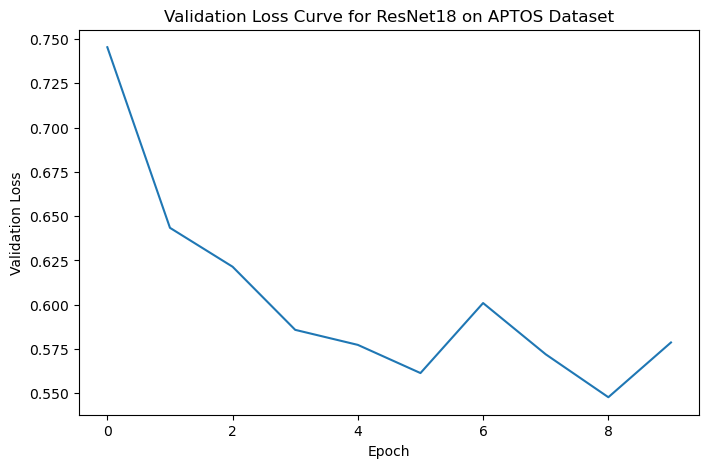

In [4]:
np.random.seed(25)
torch.manual_seed(25)
torch.mps.manual_seed(25)

resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 5)
resnet_model = resnet_model.to(device)

print(f"Number of trainable parameters: {count_trainable(resnet_model)}")
print(f"The total number of parameters in the model is: {sum(p.numel() for p in resnet_model.parameters())}")

N = len(aptos_dataset)
index = np.random.permutation(N)

train_index = index[:int(0.7*N)]
val_index  = index[int(0.7*N):int(0.85*N)]
test_index = index[int(0.85*N):]

train_dataset = Subset(aptos_dataset, train_index)
val_dataset   = Subset(aptos_dataset, val_index)
test_dataset  = Subset(aptos_dataset, test_index)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

learning_rate = 1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=learning_rate)
epochs = 10 
print("Entering training loop")
val_loss_history = train_loop_val_loss(train_dataloader, val_dataloader, resnet_model, loss_fn, optimizer, epochs, patience=5)

plt.figure(figsize=(8, 5))
plt.plot(val_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve for ResNet18 on APTOS Dataset")
plt.show()


In [ ]:
pred_list, y_list = test_loop(test_dataloader, resnet_model, loss_fn)

pred_array = torch.tensor(pred_list)
y_array = torch.tensor(y_list)

pred_array_softmax = torch.softmax(pred_array, dim=1)
pred_labels = torch.argmax(pred_array_softmax, dim=1)

accuracy_score = (pred_labels == y_array).float().mean().item()
print(f"Test Accuracy: {accuracy_score*100:.2f}%")
print(f"Cohen's Kappa Score: {cohen_kappa_score(y_array.cpu(), pred_labels.cpu()):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_array.cpu(), pred_labels.cpu()))

Test Accuracy: 77.45%
Cohen's Kappa Score: 0.6404
Confusion Matrix:
[[279   2   3   0   0]
 [  7  25  28   0   1]
 [  7  11 112   0   3]
 [  1   0  24   1   6]
 [  0   1  30   0   9]]


#### **Problem 6.17**: Ordinal Imbalance & Focal Loss

In [3]:
np.random.seed(25)
torch.manual_seed(25)
torch.mps.manual_seed(25)

resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 5)
resnet_model = resnet_model.to(device)

print(f"Number of trainable parameters: {count_trainable(resnet_model)}")
print(f"The total number of parameters in the model is: {sum(p.numel() for p in resnet_model.parameters())}")

N = len(aptos_dataset)
index = np.random.permutation(N)

train_index = index[:int(0.7*N)]
val_index  = index[int(0.7*N):int(0.85*N)]
test_index = index[int(0.85*N):]

train_dataset = Subset(aptos_dataset, train_index)
val_dataset   = Subset(aptos_dataset, val_index)
test_dataset  = Subset(aptos_dataset, test_index)

train_dataloader = DataLoader(train_dataset, batch_size= 32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size= 32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

learning_rate = 1e-3
loss_fn = focal_loss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=learning_rate)
epochs = 10 
print("Entering training loop")
val_loss_history = train_loop_val_loss(train_dataloader, val_dataloader, resnet_model, loss_fn, optimizer, epochs, patience=5)


pred_list, y_list = test_loop(test_dataloader, resnet_model, loss_fn)

pred_array = torch.tensor(pred_list)
y_array = torch.tensor(y_list)

pred_array_softmax = torch.softmax(pred_array, dim=1)
pred_labels = torch.argmax(pred_array_softmax, dim=1)

accuracy_score = (pred_labels == y_array).float().mean().item()
print(f"Test Accuracy: {accuracy_score*100:.2f}%")
print(f"Cohen's Kappa Score: {cohen_kappa_score(y_array.cpu(), pred_labels.cpu()):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_array.cpu(), pred_labels.cpu()))

Number of trainable parameters: 2565
The total number of parameters in the model is: 11179077
Entering training loop
Epoch 0: Training Loss: 0.5677, Validation Loss: 0.4168
Epoch 1: Training Loss: 0.4003, Validation Loss: 0.3401
Epoch 2: Training Loss: 0.3482, Validation Loss: 0.3637
Epoch 3: Training Loss: 0.3239, Validation Loss: 0.2936
Epoch 4: Training Loss: 0.3055, Validation Loss: 0.2946
Epoch 5: Training Loss: 0.2957, Validation Loss: 0.2831
Epoch 6: Training Loss: 0.2714, Validation Loss: 0.2998
Epoch 7: Training Loss: 0.2808, Validation Loss: 0.3094
Epoch 8: Training Loss: 0.2688, Validation Loss: 0.2788
Epoch 9: Training Loss: 0.2593, Validation Loss: 0.2982
Test Loss focal_loss: 0.3388
Test Accuracy: 78.00%
Cohen's Kappa Score: 0.6496
Confusion Matrix:
[[278   2   4   0   0]
 [  6  24  30   0   1]
 [  5   9 117   0   2]
 [  0   0  25   2   5]
 [  0   0  32   0   8]]
